In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [3]:
diffusion = np.load('paper_results/predictions/diffusion/short_training_results.npz')

diffusion['real_pollutants_re']

array([1.18320315, 0.31091415, 0.44196198, 0.23960548])

In [160]:
same_window_vunet = [
    np.load('paper_results/predictions/vunet/all/t1_same_window_results.npz'),
    np.load('paper_results/predictions/vunet/all/t2_same_window_results.npz'),
    np.load('paper_results/predictions/vunet/all/t3_same_window_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_same_window_results.npz'),
    np.load('paper_results/predictions/vunet/all/t6_same_window_results.npz'),
    np.load('paper_results/predictions/vunet/all/t8_same_window_results.npz'),
    np.load('paper_results/predictions/vunet/all/t12_same_window_results.npz')
]

diff_window_vunet = [
    np.load('paper_results/predictions/vunet/t1_42_results.npz'),
    np.load('paper_results/predictions/vunet/t2_42_results.npz'),
    np.load('paper_results/predictions/vunet/t3_42_results.npz'),
    np.load('paper_results/predictions/vunet/t4_42_results.npz'),
    np.load('paper_results/predictions/vunet/t6_42_results.npz'),
    np.load('paper_results/predictions/vunet/t8_42_results.npz'),
    np.load('paper_results/predictions/vunet/t12_42_results.npz'),
]

same_window_vitae = [
    np.load('paper_results/predictions/vitae/all/t1_same_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t2_same_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t3_same_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t4_same_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t6_same_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t8_same_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t12_same_window_results.npz')
]

diff_window_vitae = [
    np.load('paper_results/predictions/vitae/all/t1_diff_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t2_diff_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t3_diff_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t4_diff_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t6_diff_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t8_diff_window_results.npz'),
    np.load('paper_results/predictions/vitae/all/t12_diff_window_results.npz'),
]

same_window_clstm = [
    np.load('paper_results/predictions/clstm/all/t1_same_window_results.npz'),
    np.load('paper_results/predictions/clstm/all/t2_same_window_results.npz'),
    np.load('paper_results/predictions/clstm/all/t3_same_window_results.npz'),
    np.load('paper_results/predictions/clstm/all/t4_same_window_results.npz'),
    np.load('paper_results/predictions/clstm/all/t6_same_window_results.npz'),
    np.load('paper_results/predictions/clstm/all/t8_same_window_results.npz'),
    np.load('paper_results/predictions/clstm/all/t12_same_window_results.npz')
]

diff_window_clstm = [
    np.load('paper_results/predictions/clstm/t1_42_results.npz'),
    np.load('paper_results/predictions/clstm/t2_42_results.npz'),
    np.load('paper_results/predictions/clstm/t3_42_results.npz'),
    np.load('paper_results/predictions/clstm/t4_42_results.npz'),
    np.load('paper_results/predictions/clstm/t6_42_results.npz'),
    np.load('paper_results/predictions/clstm/t8_42_results.npz'),
    np.load('paper_results/predictions/clstm/t12_42_results.npz'),
]

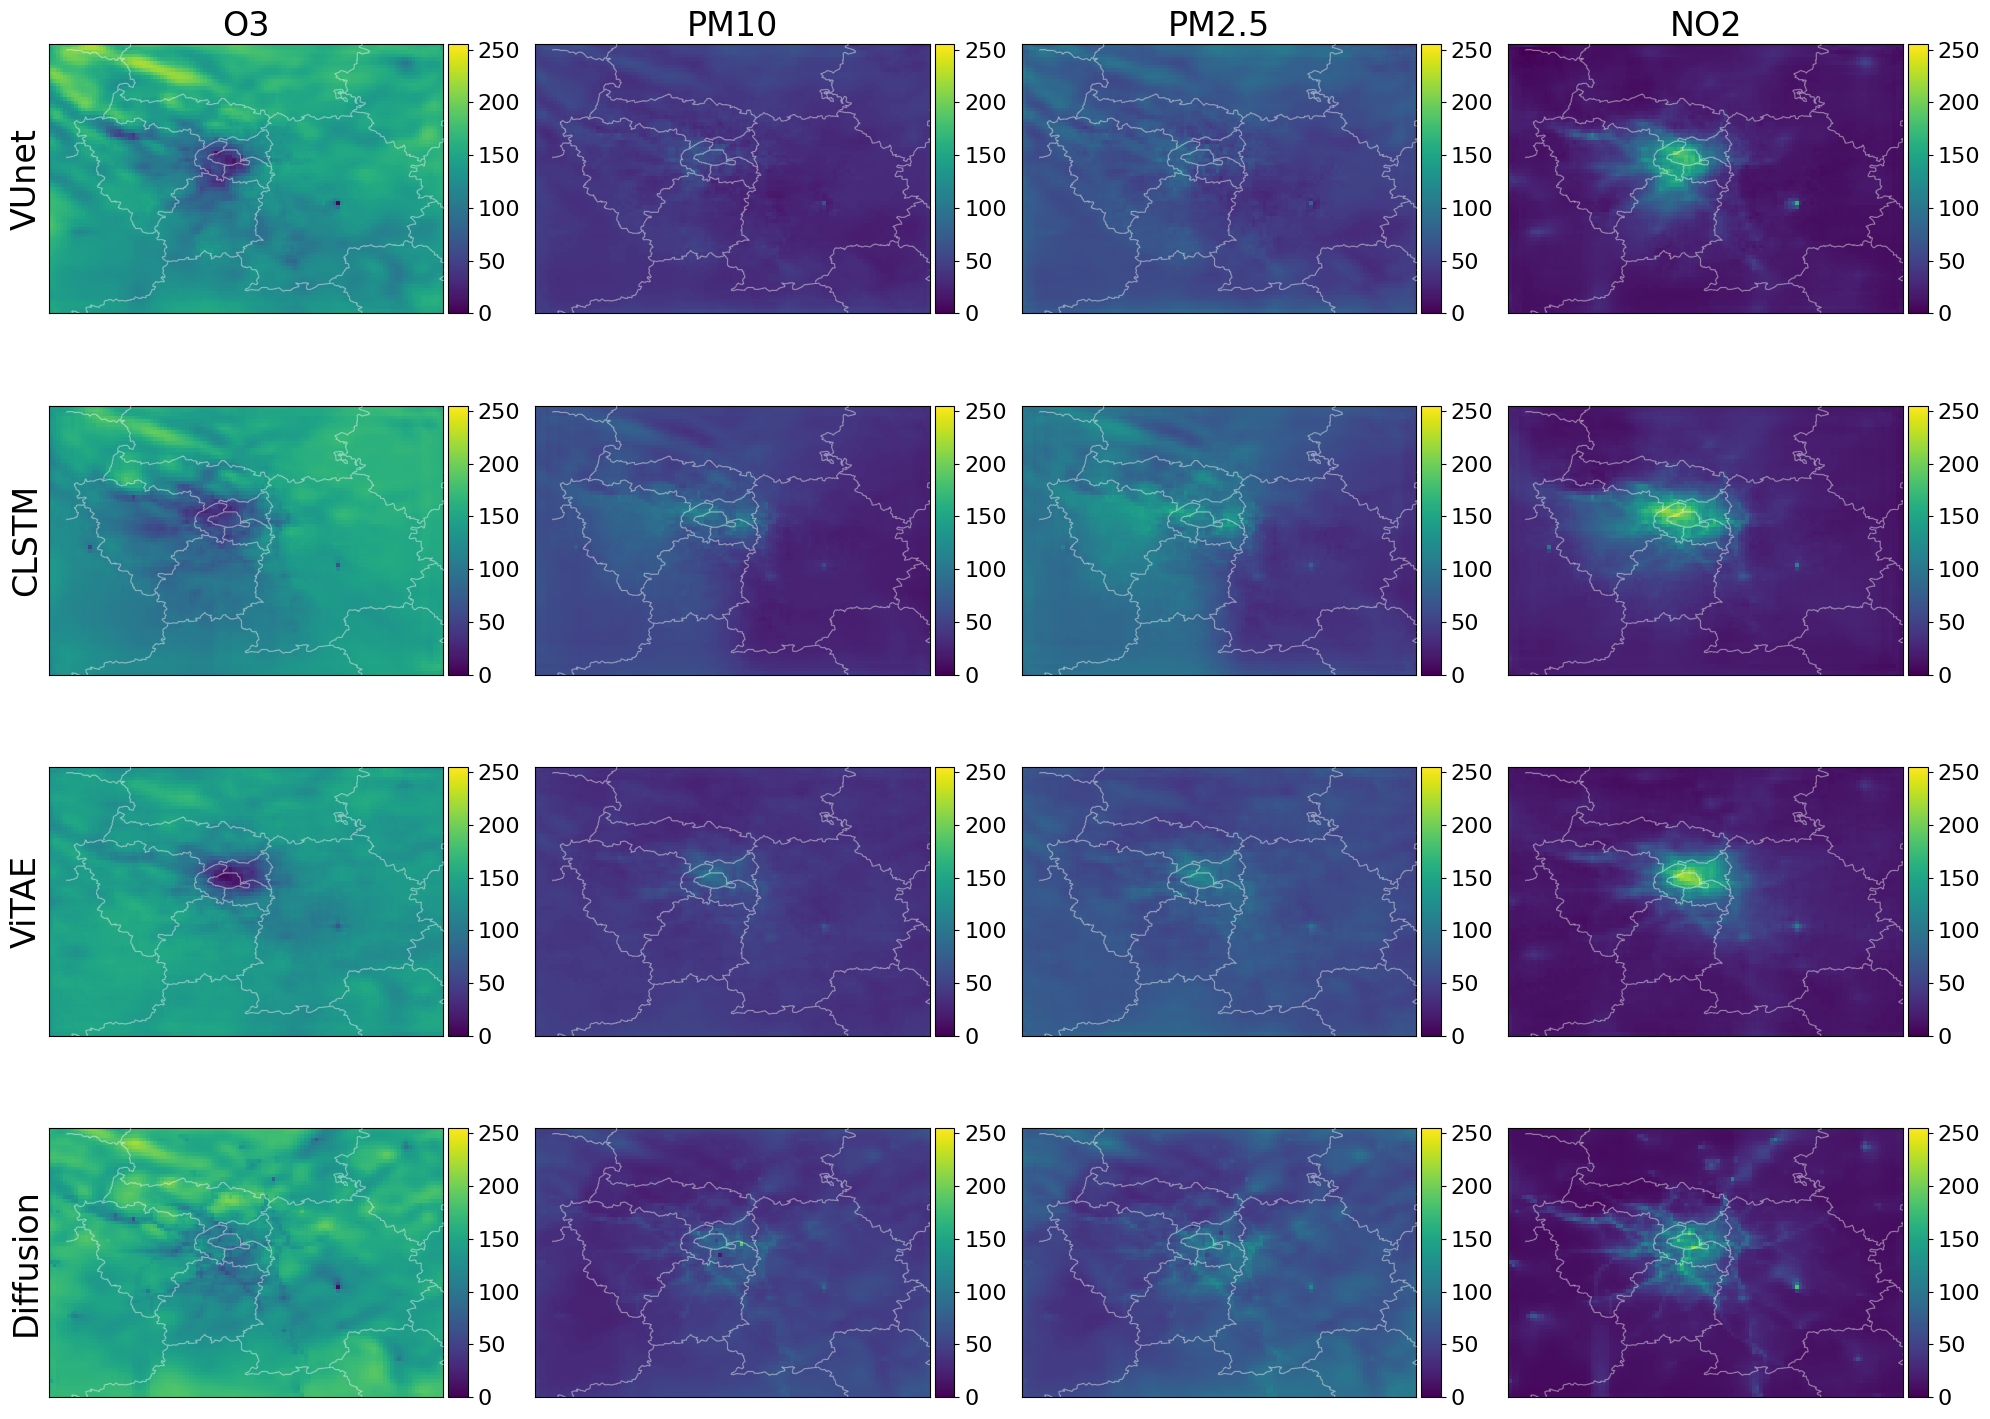

In [187]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
background_paris = np.load("data/map_rgb_adjusted.npy")

def print_with_borders(img: np.array, ax, vmax: int):
    img_rgb = background_paris.astype(np.uint8)
    mask_lines = (img_rgb < 250).any(axis=2)
    img_rgb[mask_lines] = [255, 255, 255]
    alpha = (mask_lines * 255 * 0.5).astype(np.uint8)
    paris_rgba = np.dstack([img_rgb, alpha])

    ax.imshow(
        np.flipud(img), vmin=0, vmax=vmax, 
        cmap='viridis',
        extent=[0, 110, 0, 75])
    im = ax.imshow(
        paris_rgba,
        origin="upper",          
        extent=[0, 110, 0, 75],
        zorder=10                
    )

    return im

shown_timestep = 300

models_predictions = [
    ("VUnet", diff_window_vunet[3]['real_predictions']),
    ("CLSTM", diff_window_clstm[5]['real_predictions']),
    ("ViTAE", diff_window_vitae[4]['real_predictions']),
    ("Diffusion", np.load('paper_results/predictions/diffusion/gaussian_fixed_results.npz')['real_predictions']),
]

v_max = [
    np.ceil(np.max([preds[shown_timestep, 0] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 1] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 2] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 3] for _, preds in models_predictions]) / 10 + 1) * 10
]

fig, axs = plt.subplots(len(models_predictions), 4, figsize=(20, 15))
bar_tick_size = 16
label_size = 24

for idx, (model, preds) in enumerate(models_predictions):

    im = print_with_borders(preds[shown_timestep, 0], axs[idx][0], v_max[0])
    divider = make_axes_locatable(axs[idx][0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 1], axs[idx][1], v_max[1])
    divider = make_axes_locatable(axs[idx][1])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 2], axs[idx][2], v_max[2])
    divider = make_axes_locatable(axs[idx][2])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 3], axs[idx][3], v_max[3])
    divider = make_axes_locatable(axs[idx][3])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    if idx == 0:
        axs[idx][0].set_title('O3', fontsize=label_size)
        axs[idx][1].set_title('PM10', fontsize=label_size)
        axs[idx][2].set_title('PM2.5', fontsize=label_size)
        axs[idx][3].set_title('NO2', fontsize=label_size)

    axs[idx][0].set_ylabel(model, fontsize=label_size)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("paper_images/real_predictions_diff_window.png", dpi=300, bbox_inches="tight")

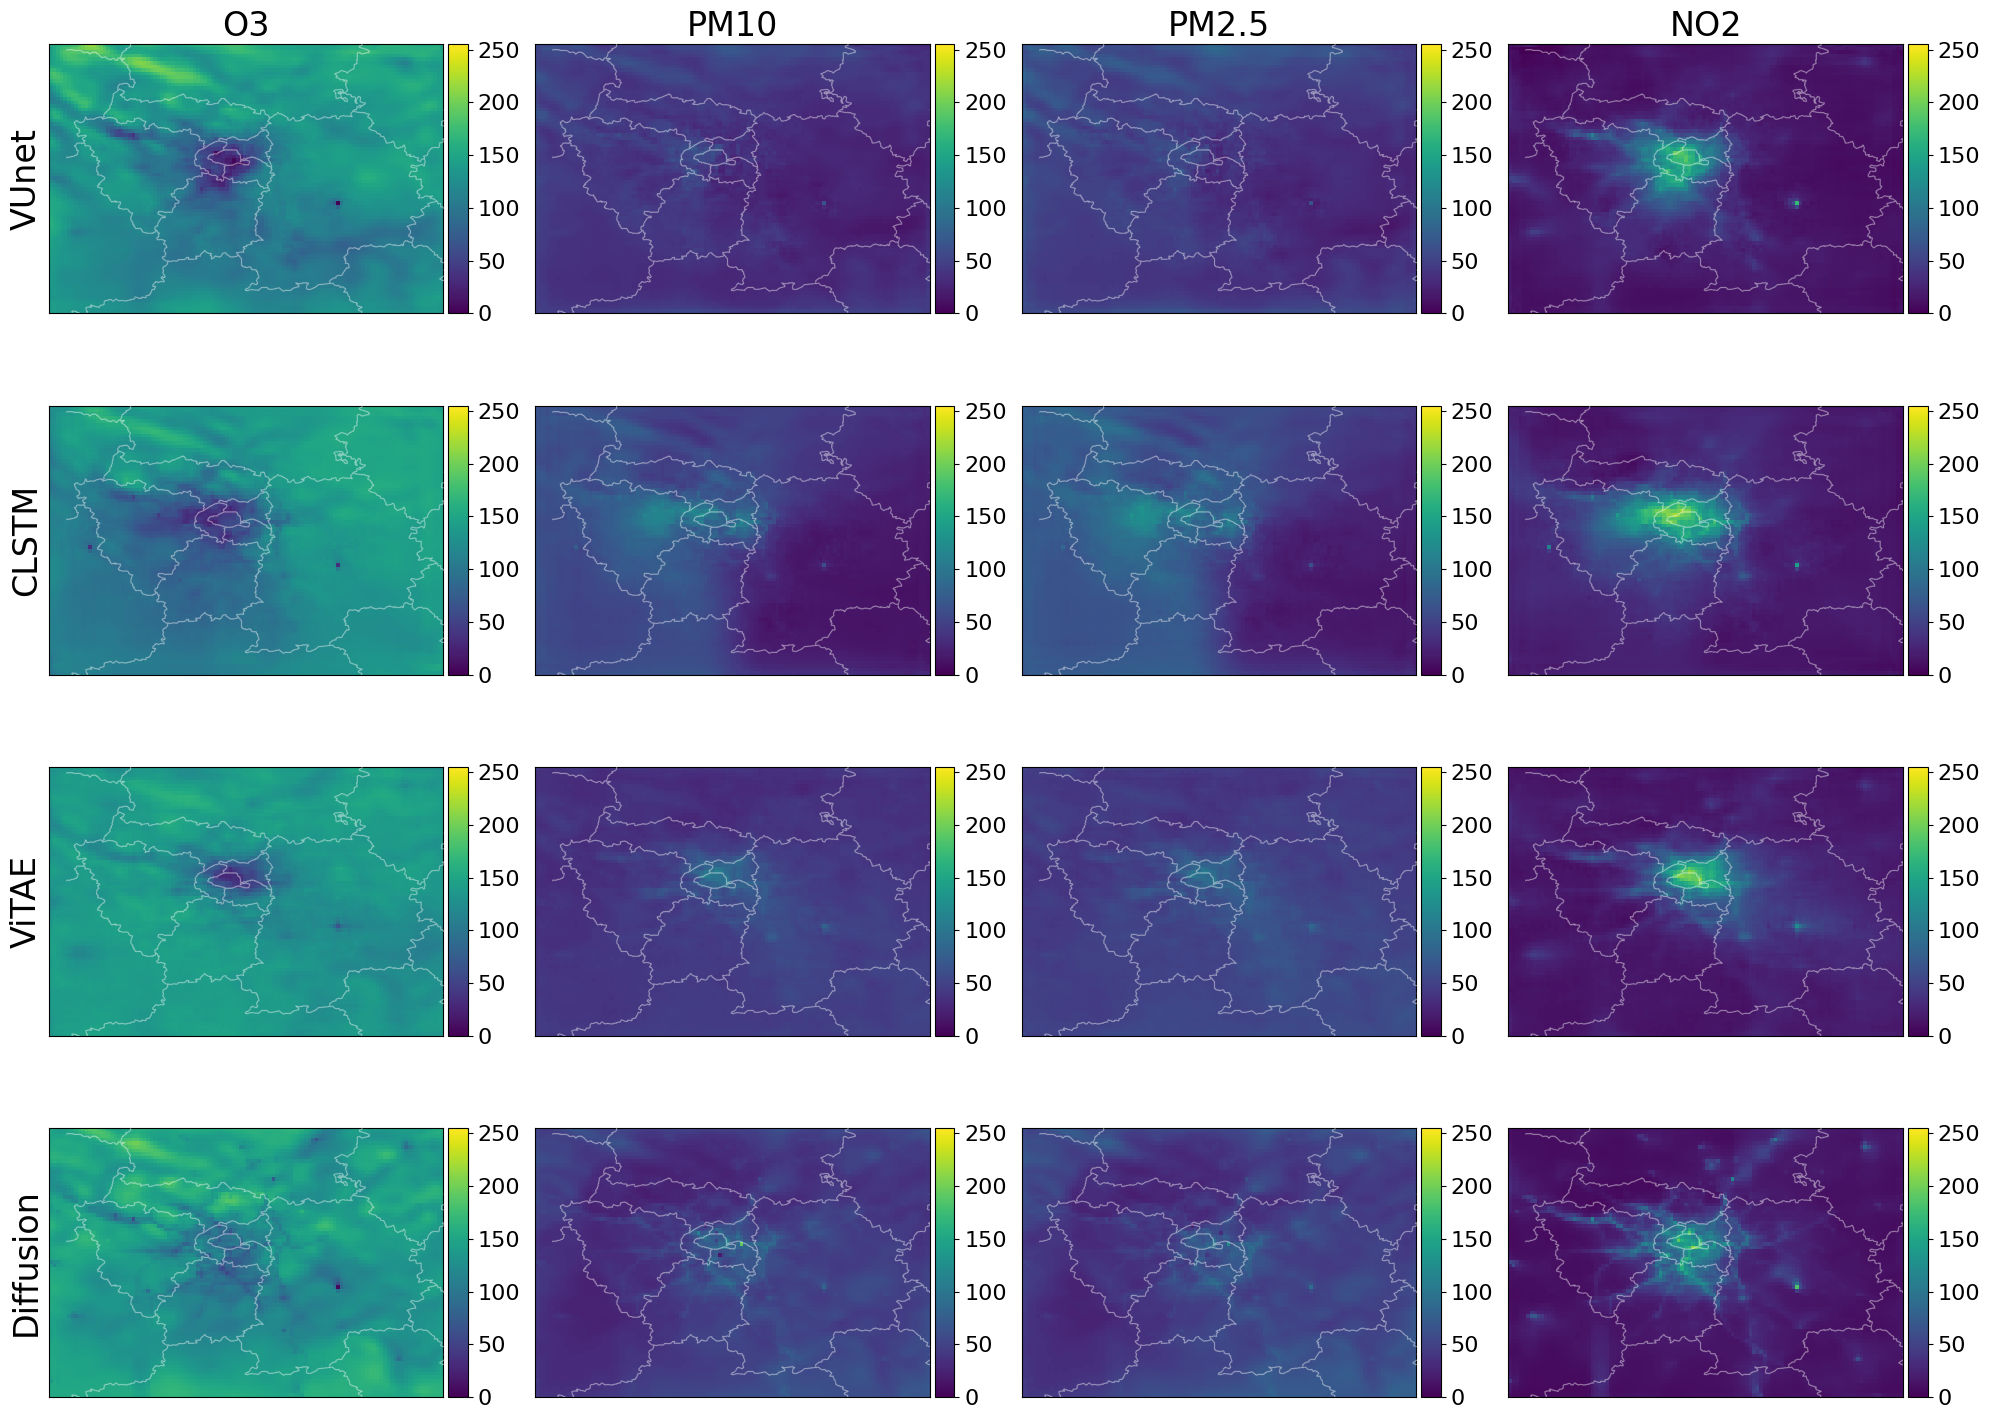

In [188]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
background_paris = np.load("data/map_rgb_adjusted.npy")

def print_with_borders(img: np.array, ax, vmax: int):
    img_rgb = background_paris.astype(np.uint8)
    mask_lines = (img_rgb < 250).any(axis=2)
    img_rgb[mask_lines] = [255, 255, 255]
    alpha = (mask_lines * 255 * 0.5).astype(np.uint8)
    paris_rgba = np.dstack([img_rgb, alpha])

    ax.imshow(
        np.flipud(img), vmin=0, vmax=vmax, 
        cmap='viridis',
        extent=[0, 110, 0, 75])
    im = ax.imshow(
        paris_rgba,
        origin="upper",          
        extent=[0, 110, 0, 75],
        zorder=10                
    )

    return im

shown_timestep = 300

models_predictions = [
    ("VUnet", same_window_vunet[3]['real_predictions']),
    ("CLSTM", same_window_clstm[5]['real_predictions']),
    ("ViTAE", same_window_vitae[4]['real_predictions']),
    ("Diffusion", np.load('paper_results/predictions/diffusion/gaussian_fixed_results.npz')['real_predictions']),
]

v_max = [
    np.ceil(np.max([preds[shown_timestep, 0] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 1] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 2] for _, preds in models_predictions]) / 10 + 1) * 10,
    np.ceil(np.max([preds[shown_timestep, 3] for _, preds in models_predictions]) / 10 + 1) * 10
]

fig, axs = plt.subplots(len(models_predictions), 4, figsize=(20, 15))
bar_tick_size = 16
label_size = 24

for idx, (model, preds) in enumerate(models_predictions):

    im = print_with_borders(preds[shown_timestep, 0], axs[idx][0], v_max[0])
    divider = make_axes_locatable(axs[idx][0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 1], axs[idx][1], v_max[1])
    divider = make_axes_locatable(axs[idx][1])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 2], axs[idx][2], v_max[2])
    divider = make_axes_locatable(axs[idx][2])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    im = print_with_borders(preds[shown_timestep, 3], axs[idx][3], v_max[3])
    divider = make_axes_locatable(axs[idx][3])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=bar_tick_size)

    if idx == 0:
        axs[idx][0].set_title('O3', fontsize=label_size)
        axs[idx][1].set_title('PM10', fontsize=label_size)
        axs[idx][2].set_title('PM2.5', fontsize=label_size)
        axs[idx][3].set_title('NO2', fontsize=label_size)

    axs[idx][0].set_ylabel(model, fontsize=label_size)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("paper_images/real_predictions_same_window.png", dpi=300, bbox_inches="tight")

In [174]:
same_window_mre_vunet = [same_window_vunet[i]['real_global_re'] for i in range(len(same_window_vunet))] 
diff_window_mre_vunet = [diff_window_vunet[i]['real_global_re'] for i in range(len(diff_window_vunet))] 

same_window_mre_vitae = [same_window_vitae[i]['real_global_re'] for i in range(len(same_window_vitae))] 
diff_window_mre_vitae = [diff_window_vitae[i]['real_global_re'] for i in range(len(diff_window_vitae))] 

same_window_mre_clstm = [same_window_clstm[i]['real_global_re'] for i in range(len(same_window_clstm))] 
diff_window_mre_clstm = [diff_window_clstm[i]['real_global_re'] for i in range(len(diff_window_clstm))] 

In [137]:
target_mask = torch.from_numpy(np.load('data/real/real_random_target_mask.npy'))
target_mask.shape

torch.Size([8759, 4, 75, 110])

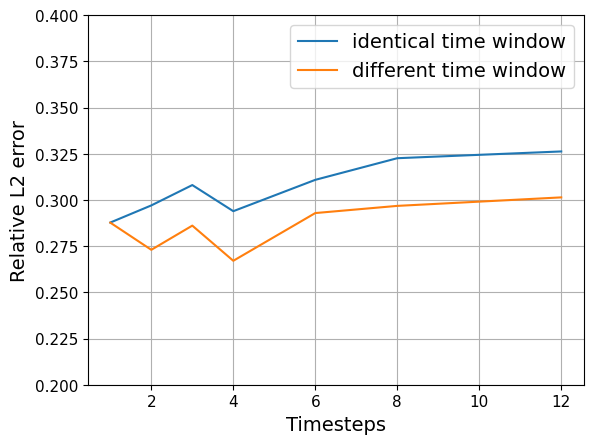

In [178]:
plt.figure()
x = [1,2,3,4,6,8,12]
plt.plot(x, same_window_mre_vunet, label='identical time window')
plt.plot(x, diff_window_mre_vunet, label='different time window')
plt.grid()
plt.ylabel('Relative L2 error', fontsize=14)
plt.xlabel('Timesteps', fontsize=14)
plt.legend(fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0.2, 0.4)
plt.savefig('paper_images/vunet_constant_time', bbox_inches='tight')

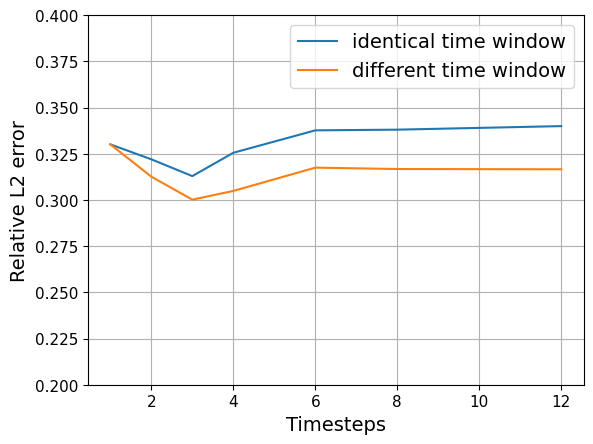

In [179]:
plt.figure()
x = [1,2,3,4,6,8,12]
plt.plot(x, same_window_mre_vitae, label='identical time window')
plt.plot(x, diff_window_mre_vitae, label='different time window')
plt.ylabel('Relative L2 error', fontsize=14)
plt.xlabel('Timesteps', fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0.2, 0.4)
plt.savefig('paper_images/vitae_constant_time', bbox_inches='tight')

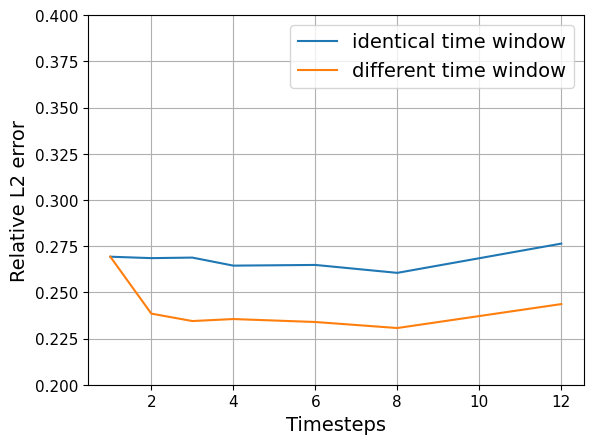

In [184]:
plt.figure()
x = [1,2,3,4,6,8,12]
plt.plot(x, same_window_mre_clstm, label='identical time window')
plt.plot(x, diff_window_mre_clstm, label='different time window')
plt.ylabel('Relative L2 error', fontsize=14)
plt.xlabel('Timesteps', fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0.2, 0.4)
plt.savefig('paper_images/clstm_constant_time', bbox_inches='tight')

# Inner vs outter city

In [118]:
vitae_inner_same_window = [
    np.load('paper_results/predictions/vitae/all/t1_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vitae/all/t2_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vitae/all/t3_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vitae/all/t4_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vitae/all/t6_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vitae/all/t8_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vitae/all/t12_same_window_inner_results.npz'),
]
vitae_outer_same_window = [
    np.load('paper_results/predictions/vitae/all/t1_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vitae/all/t2_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vitae/all/t3_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vitae/all/t4_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vitae/all/t6_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vitae/all/t8_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vitae/all/t12_same_window_outer_results.npz'),
]

vunet_inner_same_window = [
    np.load('paper_results/predictions/vunet/all/t1_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vunet/all/t2_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vunet/all/t3_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vunet/all/t6_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vunet/all/t8_same_window_inner_results.npz'),
    np.load('paper_results/predictions/vunet/all/t12_same_window_inner_results.npz'),
]
vunet_outer_same_window = [
    np.load('paper_results/predictions/vunet/all/t1_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vunet/all/t2_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vunet/all/t3_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vunet/all/t4_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vunet/all/t6_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vunet/all/t8_same_window_outer_results.npz'),
    np.load('paper_results/predictions/vunet/all/t12_same_window_outer_results.npz'),
]

clstm_inner_same_window = [
    np.load('paper_results/predictions/clstm/all/t1_same_window_inner_results.npz'),
    np.load('paper_results/predictions/clstm/all/t2_same_window_inner_results.npz'),
    np.load('paper_results/predictions/clstm/all/t3_same_window_inner_results.npz'),
    np.load('paper_results/predictions/clstm/all/t4_same_window_inner_results.npz'),
    np.load('paper_results/predictions/clstm/all/t6_same_window_inner_results.npz'),
    np.load('paper_results/predictions/clstm/all/t8_same_window_inner_results.npz'),
    np.load('paper_results/predictions/clstm/all/t12_same_window_inner_results.npz'),
]
clstm_outer_same_window = [
    np.load('paper_results/predictions/clstm/all/t1_same_window_outer_results.npz'),
    np.load('paper_results/predictions/clstm/all/t2_same_window_outer_results.npz'),
    np.load('paper_results/predictions/clstm/all/t3_same_window_outer_results.npz'),
    np.load('paper_results/predictions/clstm/all/t4_same_window_outer_results.npz'),
    np.load('paper_results/predictions/clstm/all/t6_same_window_outer_results.npz'),
    np.load('paper_results/predictions/clstm/all/t8_same_window_outer_results.npz'),
    np.load('paper_results/predictions/clstm/all/t12_same_window_outer_results.npz'),
]

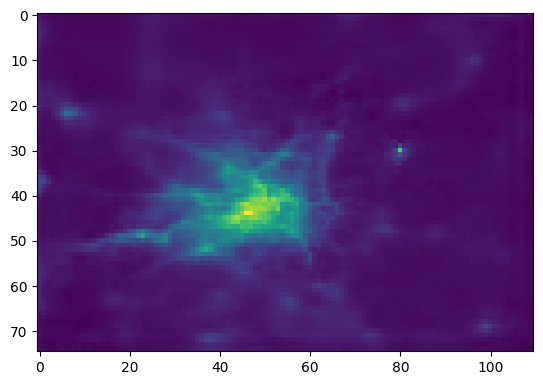

In [131]:
plt.imshow(vunet_inner_same_window[4]['real_predictions'][300][3])

In [41]:
o3_inner_same_window = [clstm_inner_same_window[i]['real_pollutants_re'][1].mean() for i in range(len(clstm_inner_same_window))]
o3_inner_same_window

[np.float64(0.32740125154810434),
 np.float64(0.32215275251447956),
 np.float64(0.3225050878014438),
 np.float64(0.31743161399460185),
 np.float64(0.3214216563033289),
 np.float64(0.32280521507551463),
 np.float64(0.34179438604743684)]

In [178]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_inner_vs_outer_grid(
    vunet_inner, vunet_outer,
    vitae_inner, vitae_outer,
    clstm_inner, clstm_outer
):

    t = [1, 2, 3, 4, 6, 8, 12]

    colors = [
        "#0072B2",  # blue
        "#009E73",  # green
        "#E69F00",  # orange
        "#CC79A7",  # purple
    ]

    # --------------------------------------------------
    # Create data for one model
    # --------------------------------------------------

    def extract_data(inner, outer):

        no2_inner = [
            inner[i]['real_pollutants_re'][3].mean()
            for i in range(len(inner))
        ]
        o3_inner = [
            inner[i]['real_pollutants_re'][0].mean()
            for i in range(len(inner))
        ]
        pm10_inner = [
            inner[i]['real_pollutants_re'][1].mean()
            for i in range(len(inner))
        ]
        pm25_inner = [
            inner[i]['real_pollutants_re'][2].mean()
            for i in range(len(inner))
        ]

        no2_outer = [
            outer[i]['real_pollutants_re'][3].mean()
            for i in range(len(outer))
        ]
        o3_outer = [
            outer[i]['real_pollutants_re'][0].mean()
            for i in range(len(outer))
        ]
        pm10_outer = [
            outer[i]['real_pollutants_re'][1].mean()
            for i in range(len(outer))
        ]
        pm25_outer = [
            outer[i]['real_pollutants_re'][2].mean()
            for i in range(len(outer))
        ]

        return [
            (no2_inner, colors[0], "-"),
            (o3_inner, colors[1], "-"),
            (pm10_inner, colors[2], "-"),
            (pm25_inner, colors[3], "-"),
            (no2_outer, colors[0], "--"),
            (o3_outer, colors[1], "--"),
            (pm10_outer, colors[2], "--"),
            (pm25_outer, colors[3], "--"),
        ]

    # --------------------------------------------------
    # Models
    # --------------------------------------------------

    models = [
        ("VUNet", vunet_inner, vunet_outer),
        ("ViTAE", vitae_inner, vitae_outer),
        ("CLSTM", clstm_inner, clstm_outer),
    ]

    # --------------------------------------------------
    # Create 2 x 3 grid
    #
    # Top row:    y = 1 to 4
    # Bottom row: y = 0 to 1
    # --------------------------------------------------

    fig, axes = plt.subplots(
        2, 3,
        sharex='col',
        figsize=(15, 6),
        gridspec_kw={
            "height_ratios": [1, 2],
            "hspace": 0.1,
            "wspace": 0.15
        }
    )

    # --------------------------------------------------
    # Plot each model
    # --------------------------------------------------

    for col, (model_name, inner, outer) in enumerate(models):

        ax_top = axes[0, col]
        ax_bottom = axes[1, col]

        lines = extract_data(inner, outer)

        # Plot lines on both parts of broken axis
        for y, color, linestyle in lines:

            ax_top.plot(
                t, y,
                color=color,
                linestyle=linestyle,
                linewidth=1.5
            )

            ax_bottom.plot(
                t, y,
                color=color,
                linestyle=linestyle,
                linewidth=1.5
            )

        # Axis limits
        ax_top.set_ylim(1, 4)
        ax_bottom.set_ylim(0, 1)

        # Title
        ax_top.set_title(
            model_name,
            fontsize=20,
            pad=10
        )

        # Grid
        ax_top.grid(True, alpha=0.3)
        ax_bottom.grid(True, alpha=0.3)

        # Hide connecting spines
        ax_top.spines["bottom"].set_visible(False)
        ax_bottom.spines["top"].set_visible(False)

        ax_top.tick_params(
            axis='x',
            bottom=False,
            labelbottom=False
        )

        # Tick sizes
        ax_top.tick_params(
            axis='both',
            which='major',
            labelsize=17,
            length=6,
            width=1.2
        )

        ax_bottom.tick_params(
            axis='both',
            which='major',
            labelsize=17,
            length=6,
            width=1.2
        )

        # --------------------------------------------------
        # Broken-axis diagonal marks
        # --------------------------------------------------

        d = 0.012

        kwargs_top = dict(
            transform=ax_top.transAxes,
            color="k",
            clip_on=False
        )

        ax_top.plot(
            (-d, +d),
            (-d, +d),
            **kwargs_top
        )

        ax_top.plot(
            (1 - d, 1 + d),
            (-d, +d),
            **kwargs_top
        )

        kwargs_bottom = dict(
            transform=ax_bottom.transAxes,
            color="k",
            clip_on=False
        )

        ax_bottom.plot(
            (-d, +d),
            (1 - d, 1 + d),
            **kwargs_bottom
        )

        ax_bottom.plot(
            (1 - d, 1 + d),
            (1 - d, 1 + d),
            **kwargs_bottom
        )

        # X-axis label under every column
        ax_bottom.set_xlabel(
            "Previous Timesteps",
            fontsize=17
        )

    # --------------------------------------------------
    # Shared Y-axis label
    # --------------------------------------------------

    fig.text(
        0.04,
        0.5,
        "Relative L2 error",
        va="center",
        rotation="vertical",
        fontsize=20
    )

    # --------------------------------------------------
    # Shared legend
    # --------------------------------------------------

    pollutant_handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor=colors[0],
            markeredgecolor=colors[0],
            markersize=8,
            label='NO₂'
        ),
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor=colors[1],
            markeredgecolor=colors[1],
            markersize=8,
            label='O₃'
        ),
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor=colors[2],
            markeredgecolor=colors[2],
            markersize=8,
            label='PM₁₀'
        ),
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor=colors[3],
            markeredgecolor=colors[3],
            markersize=8,
            label='PM₂.₅'
        ),
    ]

    location_handles = [
        Line2D(
            [0], [0],
            color='black',
            linestyle='-',
            linewidth=2,
            label='Inner'
        ),
        Line2D(
            [0], [0],
            color='black',
            linestyle='--',
            linewidth=2,
            label='Outer'
        ),
    ]

    fig.legend(
        handles=pollutant_handles + location_handles,
        labels=[
            'NO₂',
            'O₃',
            'PM₁₀',
            'PM₂.₅',
            'Inner',
            'Outer'
        ],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.04),
        fontsize=20,
        markerscale=1.6,
        ncol=6,
        frameon=False
    )

    # --------------------------------------------------
    # Layout and save
    # --------------------------------------------------

    plt.tight_layout(
        rect=[0.05, 0.0, 1.0, 0.92]
    )

    plt.savefig(
        'paper_images/inner_outer_comparison.png',
        dpi=300,
        bbox_inches='tight',
    )

    plt.show()

/tmp/ipykernel_391464/534340653.py:312: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


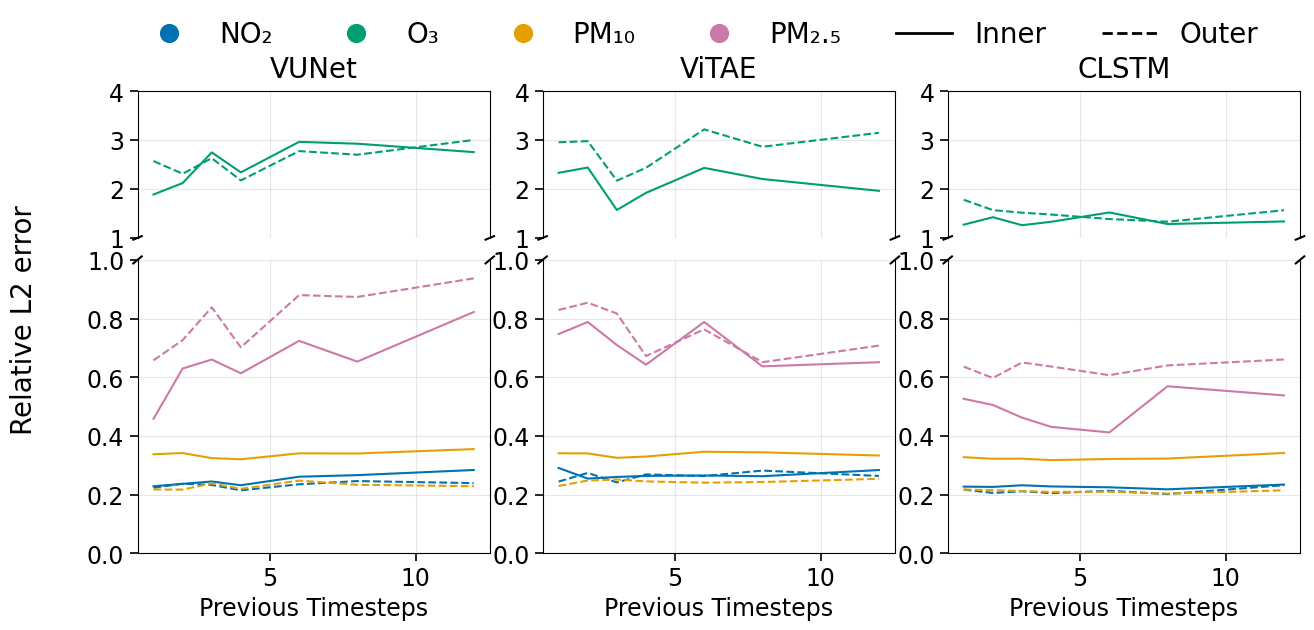

In [179]:
plot_inner_vs_outer_grid(
    vunet_inner_same_window,
    vunet_outer_same_window,
    vitae_inner_same_window,
    vitae_outer_same_window,
    clstm_inner_same_window,
    clstm_outer_same_window
)

# Inner vs Outer different window

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [114]:
vunet_diff_window = [
    np.load('paper_results/predictions/vunet/t1_42_results.npz'),
    np.load('paper_results/predictions/vunet/t2_42_results.npz'),
    np.load('paper_results/predictions/vunet/t3_42_results.npz'),
    np.load('paper_results/predictions/vunet/t4_42_results.npz'),
    np.load('paper_results/predictions/vunet/t6_42_results.npz'),
    np.load('paper_results/predictions/vunet/t8_42_results.npz'),
    np.load('paper_results/predictions/vunet/t12_42_results.npz')
]

vitae_diff_window = [
    np.load('paper_results/predictions/vitae/t1_results.npz'),
    np.load('paper_results/predictions/vitae/t2_results.npz'),
    np.load('paper_results/predictions/vitae/t3_results.npz'),
    np.load('paper_results/predictions/vitae/t4_results.npz'),
    np.load('paper_results/predictions/vitae/t6_results.npz'),
    np.load('paper_results/predictions/vitae/t8_results.npz'),
    np.load('paper_results/predictions/vitae/t12_results.npz')
]

clstm_diff_window = [
    np.load('paper_results/predictions/clstm/t1_42_results.npz'),
    np.load('paper_results/predictions/clstm/t2_42_results.npz'),
    np.load('paper_results/predictions/clstm/t3_42_results.npz'),
    np.load('paper_results/predictions/clstm/t4_42_results.npz'),
    np.load('paper_results/predictions/clstm/t6_42_results.npz'),
    np.load('paper_results/predictions/clstm/t8_42_results.npz'),
    np.load('paper_results/predictions/clstm/t12_42_results.npz'),
]


In [34]:
EPSILON = 1e-8 

def l2_norm(x: np.ndarray):
    return np.sqrt(np.sum(x ** 2))

def compute_relative_error(reference: np.ndarray, prediction: np.ndarray):
    errors = []
    for i in range(reference.shape[0]):
        error = (
            l2_norm(reference[i] - prediction[i])
            / (l2_norm(reference[i]) + EPSILON)
        )
        errors.append(error.item())
    return errors

In [44]:
def mre_inner_outer(ground_truth, prediction, target_mask):
    """
    Calculate MRE separately for inner-city and outer-city regions.

    Inner city:
        45 <= x <= 65 and 30 <= y <= 45
    """

    H, W = target_mask.shape[-2:]

    target_mask = target_mask.astype(bool)

    # Create spatial coordinate grid
    y, x = np.indices((H, W))

    # Spatial inner-city mask
    city_region = (
        (x >= 45) & (x <= 65) &
        (y >= 30) & (y <= 45)
    )

    # Broadcast spatial mask to target_mask dimensions
    reshape_dims = (1,) * (target_mask.ndim - 2) + (H,W)
    city_region = city_region.reshape(reshape_dims)

    # Valid points inside and outside the city
    inner_mask = target_mask & city_region
    outer_mask = target_mask & ~city_region

    # Apply masks
    inner_ground_truth = ground_truth *inner_mask
    inner_prediction = prediction *inner_mask

    outer_ground_truth = ground_truth*outer_mask
    outer_prediction = prediction*outer_mask

    # Calculate MRE
    inner_mre = np.mean(compute_relative_error(inner_ground_truth, inner_prediction))
    outer_mre = np.mean(compute_relative_error(outer_ground_truth, outer_prediction))

    return inner_mre, outer_mre

In [45]:
def cal_metric(result):
    vunet_inner, vunet_outer = [], []
    for k in result:
        poll_inner, poll_outer = [], []
        for i in range(4):
            inner, outer = mre_inner_outer(k['real_ground_truths'][:,i, :, :], k['real_predictions'][:,i, :, :], k['real_target_masks'][:,i, :, :])
            poll_inner.append(inner)
            poll_outer.append(outer)
        vunet_inner.append(poll_inner)
        vunet_outer.append(poll_outer)

    return vunet_inner, vunet_outer

In [46]:
vunet_inner, vunet_outer = cal_metric(vunet_diff_window)
vitae_inner, vitae_outer = cal_metric(vitae_diff_window)
clstm_inner, clstm_outer = cal_metric(clstm_diff_window)

In [47]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_inner_vs_outer_grid(
    vunet_inner, vunet_outer,
    vitae_inner, vitae_outer,
    clstm_inner, clstm_outer
):

    # Previous timesteps
    t = [1, 2, 3, 4, 6, 8, 12]

    # Colors for:
    # NO2, O3, PM10, PM2.5
    colors = [
        "#0072B2",  # blue
        "#009E73",  # green
        "#E69F00",  # orange
        "#CC79A7",  # purple
    ]

    def extract_data(inner, outer):

        # Inner
        no2_inner = [x[3] for x in inner]
        o3_inner = [x[0] for x in inner]
        pm10_inner = [x[1] for x in inner]
        pm25_inner = [x[2] for x in inner]

        # Outer
        no2_outer = [x[3] for x in outer]
        o3_outer = [x[0] for x in outer]
        pm10_outer = [x[1] for x in outer]
        pm25_outer = [x[2] for x in outer]

        return [
            # Inner -- solid lines
            (no2_inner, colors[0], "-"),
            (o3_inner, colors[1], "-"),
            (pm10_inner, colors[2], "-"),
            (pm25_inner, colors[3], "-"),

            # Outer -- dashed lines
            (no2_outer, colors[0], "--"),
            (o3_outer, colors[1], "--"),
            (pm10_outer, colors[2], "--"),
            (pm25_outer, colors[3], "--"),
        ]

    # --------------------------------------------------
    # Models
    # --------------------------------------------------

    models = [
        ("VUNet", vunet_inner, vunet_outer),
        ("ViTAE", vitae_inner, vitae_outer),
        ("CLSTM", clstm_inner, clstm_outer),
    ]

    # --------------------------------------------------
    # Create 2 x 3 grid
    #
    # Top row:    y = 1 to 4
    # Bottom row: y = 0 to 1
    # --------------------------------------------------

    fig, axes = plt.subplots(
        2,
        3,
        sharex="col",
        figsize=(15, 6),
        gridspec_kw={
            "height_ratios": [1, 2],
            "hspace": 0.1,
            "wspace": 0.15
        }
    )

    # --------------------------------------------------
    # Plot each model
    # --------------------------------------------------

    for col, (model_name, inner, outer) in enumerate(models):

        ax_top = axes[0, col]
        ax_bottom = axes[1, col]

        lines = extract_data(inner, outer)

        # --------------------------------------------------
        # Plot all pollutants
        # --------------------------------------------------

        for y, color, linestyle in lines:

            ax_top.plot(
                t,
                y,
                color=color,
                linestyle=linestyle,
                linewidth=1.5
            )

            ax_bottom.plot(
                t,
                y,
                color=color,
                linestyle=linestyle,
                linewidth=1.5
            )

        # --------------------------------------------------
        # Axis limits
        # --------------------------------------------------

        ax_top.set_ylim(1, 4)
        ax_bottom.set_ylim(0, 1)

        # --------------------------------------------------
        # Model title
        # --------------------------------------------------

        ax_top.set_title(
            model_name,
            fontsize=20,
            pad=10
        )

        # --------------------------------------------------
        # Grid
        # --------------------------------------------------

        ax_top.grid(
            True,
            alpha=0.3
        )

        ax_bottom.grid(
            True,
            alpha=0.3
        )

        # --------------------------------------------------
        # Hide connecting spines
        # --------------------------------------------------

        ax_top.spines["bottom"].set_visible(False)
        ax_bottom.spines["top"].set_visible(False)

        # --------------------------------------------------
        # Hide x-axis labels on top plot
        # --------------------------------------------------

        ax_top.tick_params(
            axis="x",
            bottom=False,
            labelbottom=False
        )

        # --------------------------------------------------
        # Tick sizes
        # --------------------------------------------------

        ax_top.tick_params(
            axis="both",
            which="major",
            labelsize=17,
            length=6,
            width=1.2
        )

        ax_bottom.tick_params(
            axis="both",
            which="major",
            labelsize=17,
            length=6,
            width=1.2
        )

        # --------------------------------------------------
        # Broken-axis diagonal marks
        # --------------------------------------------------

        d = 0.012

        # Top axis diagonal marks
        kwargs_top = dict(
            transform=ax_top.transAxes,
            color="k",
            clip_on=False
        )

        ax_top.plot(
            (-d, +d),
            (-d, +d),
            **kwargs_top
        )

        ax_top.plot(
            (1 - d, 1 + d),
            (-d, +d),
            **kwargs_top
        )

        # Bottom axis diagonal marks
        kwargs_bottom = dict(
            transform=ax_bottom.transAxes,
            color="k",
            clip_on=False
        )

        ax_bottom.plot(
            (-d, +d),
            (1 - d, 1 + d),
            **kwargs_bottom
        )

        ax_bottom.plot(
            (1 - d, 1 + d),
            (1 - d, 1 + d),
            **kwargs_bottom
        )

        # --------------------------------------------------
        # X-axis label
        # --------------------------------------------------

        ax_bottom.set_xlabel(
            "Previous Timesteps",
            fontsize=17
        )

    # --------------------------------------------------
    # Shared Y-axis label
    # --------------------------------------------------

    fig.text(
        0.04,
        0.5,
        "Relative L2 error",
        va="center",
        rotation="vertical",
        fontsize=20
    )

    # --------------------------------------------------
    # Shared legend
    # --------------------------------------------------

    pollutant_handles = [

        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=colors[0],
            markeredgecolor=colors[0],
            markersize=8,
            label="NO₂"
        ),

        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=colors[1],
            markeredgecolor=colors[1],
            markersize=8,
            label="O₃"
        ),

        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=colors[2],
            markeredgecolor=colors[2],
            markersize=8,
            label="PM₁₀"
        ),

        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=colors[3],
            markeredgecolor=colors[3],
            markersize=8,
            label="PM₂.₅"
        ),
    ]

    location_handles = [

        Line2D(
            [0],
            [0],
            color="black",
            linestyle="-",
            linewidth=2,
            label="Inner"
        ),

        Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            linewidth=2,
            label="Outer"
        ),
    ]

    fig.legend(
        handles=pollutant_handles + location_handles,
        labels=[
            "NO₂",
            "O₃",
            "PM₁₀",
            "PM₂.₅",
            "Inner",
            "Outer"
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        fontsize=20,
        markerscale=1.6,
        ncol=6,
        frameon=False
    )

    # --------------------------------------------------
    # Layout
    # --------------------------------------------------

    plt.tight_layout(
        rect=[0.05, 0.0, 1.0, 0.92]
    )

    # --------------------------------------------------
    # Save figure
    # --------------------------------------------------

    plt.savefig(
        "paper_images/inner_outer_diff_window.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

/tmp/ipykernel_592654/624833940.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


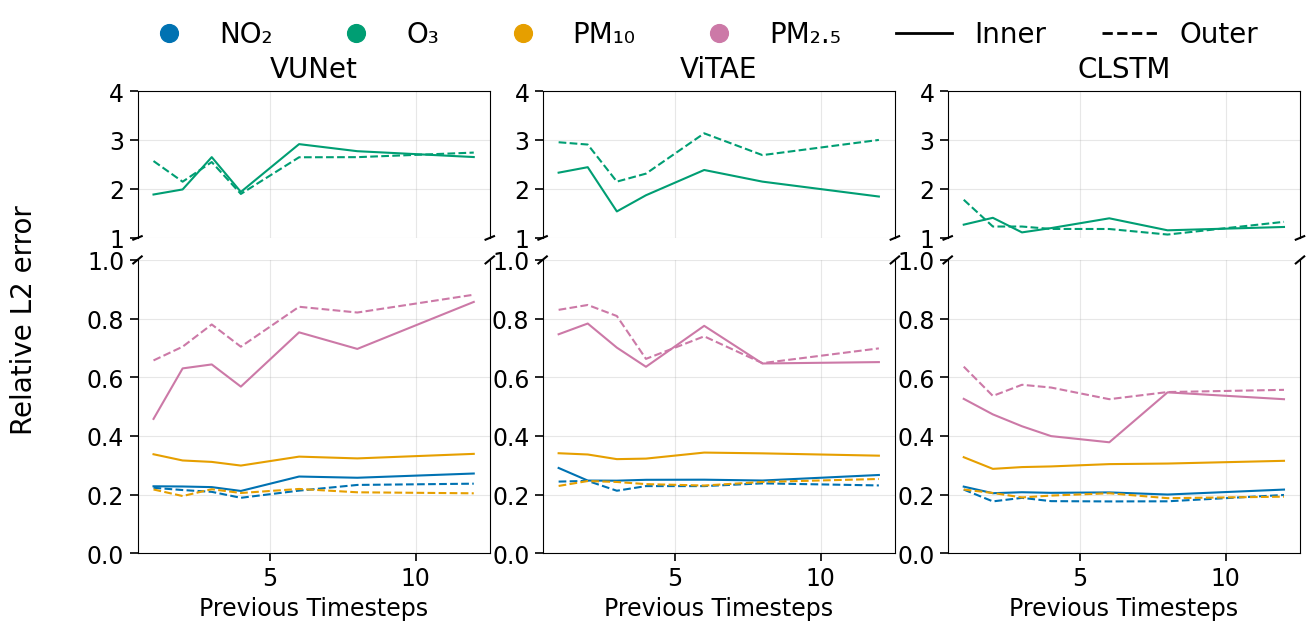

In [48]:
plot_inner_vs_outer_grid(
    vunet_inner, vunet_outer,
    vitae_inner, vitae_outer,
    clstm_inner, clstm_outer
)

# Different training seeds

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
vunet_0 = np.load('paper_results/predictions/vunet/t4_results.npz')
vunet_42 = np.load('paper_results/predictions/vunet/t4_42_results.npz')
vunet_21 = np.load('paper_results/predictions/vunet/all/t4_21_results.npz')

vitae_0 = np.load('paper_results/predictions/vitae/t6_results.npz')
vitae_42 = np.load('paper_results/predictions/vitae/t6_42_results.npz')
vitae_21 = np.load('paper_results/predictions/vitae/all/t6_21_results.npz')

clstm_0 = np.load('paper_results/predictions/clstm/t8_results.npz')
clstm_42 = np.load('paper_results/predictions/clstm/t8_42_results.npz')
clstm_21 = np.load('paper_results/predictions/clstm/all/t8_21_results.npz')

diffusion_0 = np.load('paper_results/predictions/diffusion/all/seed0_results.npz')
diffusion_21 = np.load('paper_results/predictions/diffusion/all/seed_21_results.npz')
diffusion_42 = np.load('paper_results/predictions/diffusion/short_training_results.npz')


In [48]:
def training_mean_std(a,b,c):
    seed_results = [a,b,c]

    simulated_mre = [i['simulated_global_re'] for i in seed_results]
    simulated_mre = np.array(simulated_mre)
    simulated_stats = [simulated_mre.mean(), simulated_mre.std()]

    real_mre = [i['real_global_re'] for i in seed_results]
    real_mre = np.array(real_mre)
    real_stats = [real_mre.mean(), real_mre.std()]

    return simulated_stats, simulated_mre, real_stats, real_mre

In [49]:
vunet_sim_stat, vunet_sim_mre, vunet_real_stat, vunet_real_mre = training_mean_std(vunet_0, vunet_21, vunet_42)
vitae_sim_stat, vitae_sim_mre, vitae_real_stat, vitae_real_mre = training_mean_std(vitae_0, vitae_21, vitae_42)
clstm_sim_stat, clstm_sim_mre, clstm_real_stat, clstm_real_mre = training_mean_std(clstm_0, clstm_21, clstm_42)
diffusion_sim_stat, diffusion_sim_mre, diffusion_real_stat, diffusion_real_mre = training_mean_std(diffusion_0, diffusion_21, diffusion_42)

# Temporal Block Resampling

In [28]:
import numpy as np

def temporal_block_bootstrap_ci(
    mre,
    block_size=24,
    n_bootstrap=10000,
    confidence=0.95,
    statistic=np.mean,
    random_state=42
):
    """
    Temporal block bootstrap confidence interval.

    Parameters
    ----------
    mre : array-like
        Time-ordered MRE values (e.g., hourly MRE over one month).
    block_size : int
        Number of consecutive observations per block.
        For hourly data, 24 = one day.
    n_bootstrap : int
        Number of bootstrap resamples.
    confidence : float
        Confidence level, e.g. 0.95 for a 95% CI.
    statistic : callable
        Statistic to estimate, e.g. np.mean or np.median.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    estimate : float
        Statistic calculated from the original data.
    ci_lower : float
        Lower confidence limit.
    ci_upper : float
        Upper confidence limit.
    bootstrap_statistics : ndarray
        Bootstrap distribution of the statistic.
    """

    mre = np.asarray(mre, dtype=float)
    mre = mre[np.isfinite(mre)]

    n = len(mre)

    rng = np.random.default_rng(random_state)

    # Create overlapping temporal blocks
    blocks = np.array([
        mre[i:i + block_size]
        for i in range(n - block_size + 1)
    ], dtype=object)

    # Number of blocks needed to reconstruct approximately
    # the original sample size
    n_blocks = int(np.ceil(n / block_size))

    bootstrap_statistics = np.empty(n_bootstrap)

    for b in range(n_bootstrap):

        # Randomly select blocks WITH replacement
        selected = rng.integers(
            0, len(blocks),
            size=n_blocks
        )

        # Concatenate selected blocks
        resampled = np.concatenate(
            [blocks[i] for i in selected]
        )

        # Trim to original sample size
        resampled = resampled[:n]

        # Calculate statistic
        bootstrap_statistics[b] = statistic(resampled)

    # Original estimate
    estimate = statistic(mre)

    # Percentile confidence interval
    alpha = 1 - confidence

    ci_lower = np.percentile(
        bootstrap_statistics,
        100 * alpha / 2
    )

    ci_upper = np.percentile(
        bootstrap_statistics,
        100 * (1 - alpha / 2)
    )

    return estimate, ci_lower, ci_upper, bootstrap_statistics


In [29]:
def calculate_all_model_pollutant_ci(
    vunet_mre,
    vitae_mre,
    clstm_mre,
    diffusion_mre,
    pollutant_names,
    block_size=24,
    n_bootstrap=10000,
    confidence=0.95,
    statistic=np.mean,
    random_state=42
):
    """
    Apply temporal_block_bootstrap_ci() to every
    model × pollutant combination.

    Returns
    -------
    results : dict
        Nested dictionary containing mean MRE, CI limits,
        and bootstrap distributions.
    """

    models = {
        "VUNet": vunet_mre,
        "ViTAE": vitae_mre,
        "CLSTM": clstm_mre,
        "Diffusion": diffusion_mre
    }

    results = {}

    for model_name, model_data in models.items():

        model_data = np.asarray(model_data)

        if model_data.shape[0] != len(pollutant_names):
            raise ValueError(
                f"{model_name} has {model_data.shape[0]} pollutants, "
                f"but {len(pollutant_names)} pollutant names were provided."
            )

        results[model_name] = {}

        for pollutant_idx, pollutant_name in enumerate(pollutant_names):

            mre = model_data[pollutant_idx]

            estimate, ci_lower, ci_upper, bootstrap_statistics = (
                temporal_block_bootstrap_ci(
                    mre,
                    block_size=block_size,
                    n_bootstrap=n_bootstrap,
                    confidence=confidence,
                    statistic=statistic,
                    random_state=random_state + pollutant_idx
                )
            )

            results[model_name][pollutant_name] = {
                "mean": estimate,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "bootstrap": bootstrap_statistics
            }

    return results

In [40]:
def calculate_global_model_ci(
    vunet_mre_simulation_global,
    vitae_mre_simulation_global,
    clstm_mre_simulation_global,
    diffusion_mre_simulation_global,
    vunet_mre_real_global,
    vitae_mre_real_global,
    clstm_mre_real_global,
    diffusion_mre_real_global,
    block_size=24,
    n_bootstrap=10000,
    confidence=0.95,
    statistic=np.mean,
    random_state=42
):
    """
    Apply temporal_block_bootstrap_ci() to global MRE
    time series for all models and both conditions.
    """

    models_simulation = {
        "VUNet": vunet_mre_simulation_global,
        "ViTAE": vitae_mre_simulation_global,
        "CLSTM": clstm_mre_simulation_global,
        "Diffusion": diffusion_mre_simulation_global
    }

    models_real = {
        "VUNet": vunet_mre_real_global,
        "ViTAE": vitae_mre_real_global,
        "CLSTM": clstm_mre_real_global,
        "Diffusion": diffusion_mre_real_global
    }

    results = {
        "Simulation": {},
        "Real": {}
    }

    # ---------------------------------------------------------
    # Simulation
    # ---------------------------------------------------------

    for model_idx, (model, mre) in enumerate(models_simulation.items()):

        estimate, ci_lower, ci_upper, bootstrap_statistics = (
            temporal_block_bootstrap_ci(
                mre,
                block_size=block_size,
                n_bootstrap=n_bootstrap,
                confidence=confidence,
                statistic=statistic,
                random_state=random_state + model_idx
            )
        )

        results["Simulation"][model] = {
            "mean": estimate,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "bootstrap": bootstrap_statistics
        }

    # ---------------------------------------------------------
    # Real
    # ---------------------------------------------------------

    for model_idx, (model, mre) in enumerate(models_real.items()):

        estimate, ci_lower, ci_upper, bootstrap_statistics = (
            temporal_block_bootstrap_ci(
                mre,
                block_size=block_size,
                n_bootstrap=n_bootstrap,
                confidence=confidence,
                statistic=statistic,
                random_state=random_state + model_idx
            )
        )

        results["Real"][model] = {
            "mean": estimate,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "bootstrap": bootstrap_statistics
        }

    return results

In [39]:

vunet_result = np.load('paper_results/predictions/vunet/all/temporal_results.npz')
vitae_result = np.load('paper_results/predictions/vitae/all/temporal_results.npz')
clstm_result = np.load('paper_results/predictions/clstm/all/temporal_results.npz')
diffusion_result = np.load('paper_results/predictions/diffusion/all/temporal_results.npz')

vunet_mre_simulation = vunet_result['simulated_pollutants_re']
vitae_mre_simulation = vitae_result['simulated_pollutants_re']
clstm_mre_simulation = clstm_result['simulated_pollutants_re']
diffusion_mre_simulation = diffusion_result['simulated_pollutants_re']

vunet_mre_real = vunet_result['real_pollutants_re']
vitae_mre_real = vitae_result['real_pollutants_re']
clstm_mre_real = clstm_result['real_pollutants_re']
diffusion_mre_real = diffusion_result['real_pollutants_re']

vunet_mre_simulation_global = vunet_result['simulated_global_re']
vitae_mre_simulation_global  = vitae_result['simulated_global_re']
clstm_mre_simulation_global  = clstm_result['simulated_global_re']
diffusion_mre_simulation_global  = diffusion_result['simulated_global_re']

vunet_mre_real_global  = vunet_result['real_global_re']
vitae_mre_real_global  = vitae_result['real_global_re']
clstm_mre_real_global  = clstm_result['real_global_re']
diffusion_mre_real_global  = diffusion_result['real_global_re']

In [41]:
pollutant_names = [
    "O3",
    "PM10",
    "PM2.5",
    "NO2",
]

results_simulated = calculate_all_model_pollutant_ci(
    vunet_mre=vunet_mre_simulation,
    vitae_mre=vitae_mre_simulation,
    clstm_mre=clstm_mre_simulation,
    diffusion_mre=diffusion_mre_simulation,
    pollutant_names=pollutant_names,
    block_size=24,
    n_bootstrap=10000,
    confidence=0.95,
    statistic=np.mean,
    random_state=42
)

results_real = calculate_all_model_pollutant_ci(
    vunet_mre=vunet_mre_real,
    vitae_mre=vitae_mre_real,
    clstm_mre=clstm_mre_real,
    diffusion_mre=diffusion_mre_real,
    pollutant_names=pollutant_names,
    block_size=24,
    n_bootstrap=10000,
    confidence=0.95,
    statistic=np.mean,
    random_state=42
)

results_global = calculate_global_model_ci(
    vunet_mre_simulation_global=vunet_mre_simulation_global,
    vitae_mre_simulation_global=vitae_mre_simulation_global,
    clstm_mre_simulation_global=clstm_mre_simulation_global,
    diffusion_mre_simulation_global=diffusion_mre_simulation_global,

    vunet_mre_real_global=vunet_mre_real_global,
    vitae_mre_real_global=vitae_mre_real_global,
    clstm_mre_real_global=clstm_mre_real_global,
    diffusion_mre_real_global=diffusion_mre_real_global,

    block_size=24,
    n_bootstrap=10000,
    confidence=0.95,
    statistic=np.mean,
    random_state=42
)

In [37]:
import numpy as np
import matplotlib.pyplot as plt


def plot_model_mre_ci(
    results_simulated,
    results_real,
    pollutant_names,
    model_names=None,
    figsize=(12, 9),
    save_path=None,
    dpi=600
):
    """
    Publication-quality plot of model MRE with 95% temporal-block-bootstrap CIs.

    Each pollutant has its own automatically determined y-axis range.
    MRE values are shown in their original scale, not percentages.
    """

    if model_names is None:
        model_names = [
            "VUNet",
            "ViTAE",
            "CLSTM",
            "Diffusion"
        ]

    # ---------------------------------------------------------
    # Figure setup
    # ---------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        sharey=False
    )

    axes = axes.flatten()

    x = np.arange(len(model_names))
    offset = 0.12

    # ---------------------------------------------------------
    # Plot each pollutant
    # ---------------------------------------------------------

    for ax, pollutant in zip(axes, pollutant_names):

        sim_means = []
        sim_lower = []
        sim_upper = []

        real_means = []
        real_lower = []
        real_upper = []

        for model in model_names:

            # Simulated
            sim = results_simulated[model][pollutant]

            sim_means.append(sim["mean"])
            sim_lower.append(sim["ci_lower"])
            sim_upper.append(sim["ci_upper"])

            # Real
            real = results_real[model][pollutant]

            real_means.append(real["mean"])
            real_lower.append(real["ci_lower"])
            real_upper.append(real["ci_upper"])

        sim_means = np.asarray(sim_means)
        sim_lower = np.asarray(sim_lower)
        sim_upper = np.asarray(sim_upper)

        real_means = np.asarray(real_means)
        real_lower = np.asarray(real_lower)
        real_upper = np.asarray(real_upper)

        # -----------------------------------------------------
        # Asymmetric error bars
        # -----------------------------------------------------

        sim_error = np.vstack([
            sim_means - sim_lower,
            sim_upper - sim_means
        ])

        real_error = np.vstack([
            real_means - real_lower,
            real_upper - real_means
        ])

        # -----------------------------------------------------
        # Simulation
        # -----------------------------------------------------

        ax.errorbar(
            x - offset,
            sim_means,
            yerr=sim_error,
            fmt='o',
            markersize=6,
            capsize=4,
            capthick=1.2,
            elinewidth=1.2,
            label="Simulation"
        )

        # -----------------------------------------------------
        # Real
        # -----------------------------------------------------

        ax.errorbar(
            x + offset,
            real_means,
            yerr=real_error,
            fmt='s',
            markersize=6,
            capsize=4,
            capthick=1.2,
            elinewidth=1.2,
            label="Real"
        )

        # -----------------------------------------------------
        # Pollutant-specific y-axis range
        # -----------------------------------------------------

        all_lower = np.concatenate([
            sim_lower,
            real_lower
        ])

        all_upper = np.concatenate([
            sim_upper,
            real_upper
        ])

        ymin = np.min(all_lower)
        ymax = np.max(all_upper)

        data_range = ymax - ymin

        if data_range == 0:
            data_range = max(abs(ymax), 1)

        padding = 0.10 * data_range

        ax.set_ylim(
            max(0, ymin - padding),
            ymax + padding
        )

        # -----------------------------------------------------
        # Formatting
        # -----------------------------------------------------

        ax.set_title(
            pollutant,
            fontsize=14,
            fontweight="bold",
            pad=10
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            model_names,
            fontsize=11
        )

        ax.tick_params(
            axis='y',
            labelsize=10
        )

        ax.grid(
            axis='y',
            linestyle='--',
            linewidth=0.7,
            alpha=0.4
        )

        ax.set_axisbelow(True)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # ---------------------------------------------------------
    # Common labels
    # ---------------------------------------------------------

    fig.text(
        0.5,
        0.03,
        "Model",
        ha="center",
        fontsize=13
    )

    fig.text(
        0.025,
        0.5,
        "Mean Relative Error (MRE)",
        va="center",
        rotation="vertical",
        fontsize=13
    )

    # ---------------------------------------------------------
    # Common legend
    # ---------------------------------------------------------

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=2,
        frameon=False,
        fontsize=11
    )

    # ---------------------------------------------------------
    # Layout
    # ---------------------------------------------------------

    plt.subplots_adjust(
        left=0.10,
        right=0.98,
        bottom=0.10,
        top=0.90,
        wspace=0.15,
        hspace=0.25
    )

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return fig, axes

In [42]:

def plot_global_mre_ci(
    results_global,
    model_names=None,
    figsize=(8, 6),
    save_path=None,
    dpi=600
):

    if model_names is None:
        model_names = [
            "VUNet",
            "ViTAE",
            "CLSTM",
            "Diffusion"
        ]

    x = np.arange(len(model_names))
    offset = 0.12

    fig, ax = plt.subplots(
        figsize=figsize
    )

    # ---------------------------------------------------------
    # Simulation
    # ---------------------------------------------------------

    sim_mean = np.array([
        results_global["Simulation"][model]["mean"]
        for model in model_names
    ])

    sim_lower = np.array([
        results_global["Simulation"][model]["ci_lower"]
        for model in model_names
    ])

    sim_upper = np.array([
        results_global["Simulation"][model]["ci_upper"]
        for model in model_names
    ])

    sim_error = np.vstack([
        sim_mean - sim_lower,
        sim_upper - sim_mean
    ])

    ax.errorbar(
        x - offset,
        sim_mean,
        yerr=sim_error,
        fmt="o",
        markersize=7,
        capsize=5,
        capthick=1.3,
        elinewidth=1.3,
        label="Simulation"
    )

    # ---------------------------------------------------------
    # Real
    # ---------------------------------------------------------

    real_mean = np.array([
        results_global["Real"][model]["mean"]
        for model in model_names
    ])

    real_lower = np.array([
        results_global["Real"][model]["ci_lower"]
        for model in model_names
    ])

    real_upper = np.array([
        results_global["Real"][model]["ci_upper"]
        for model in model_names
    ])

    real_error = np.vstack([
        real_mean - real_lower,
        real_upper - real_mean
    ])

    ax.errorbar(
        x + offset,
        real_mean,
        yerr=real_error,
        fmt="s",
        markersize=7,
        capsize=5,
        capthick=1.3,
        elinewidth=1.3,
        label="Real"
    )

    # ---------------------------------------------------------
    # Automatic y-axis range
    # ---------------------------------------------------------

    all_lower = np.concatenate([
        sim_lower,
        real_lower
    ])

    all_upper = np.concatenate([
        sim_upper,
        real_upper
    ])

    ymin = np.min(all_lower)
    ymax = np.max(all_upper)

    data_range = ymax - ymin

    if data_range == 0:
        data_range = max(abs(ymax), 1)

    padding = 0.10 * data_range

    ax.set_ylim(
        max(0, ymin - padding),
        ymax + padding
    )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(
        model_names,
        fontsize=12
    )

    ax.set_ylabel(
        "Global Mean Relative Error (MRE)",
        fontsize=13
    )

    ax.tick_params(
        axis="y",
        labelsize=11
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.4
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=11,
        loc="upper left"
    )

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return fig, ax

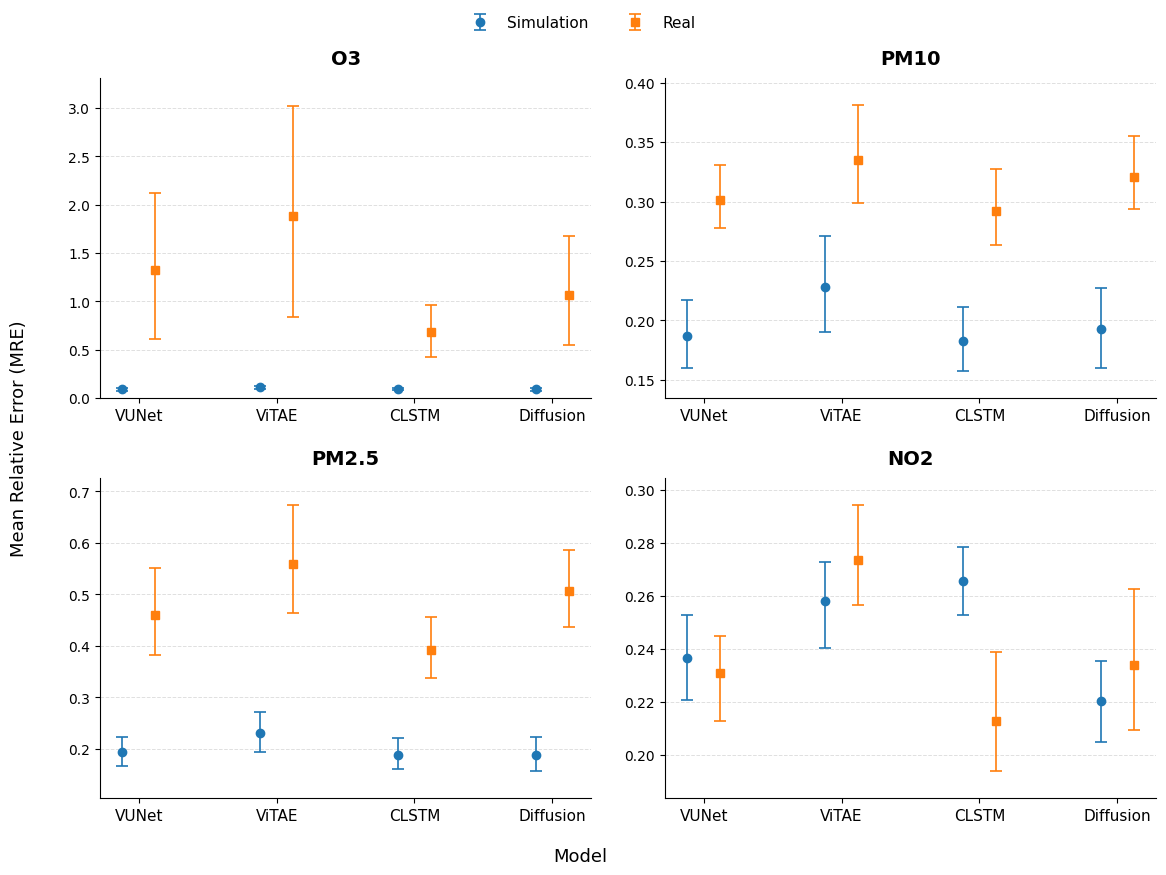

In [38]:
fig, axes = plot_model_mre_ci(
    results_simulated=results_simulated,
    results_real=results_real,
    pollutant_names=pollutant_names,
    save_path="paper_images/model_MRE_temporal_block_bootstrap_CI.png"
)

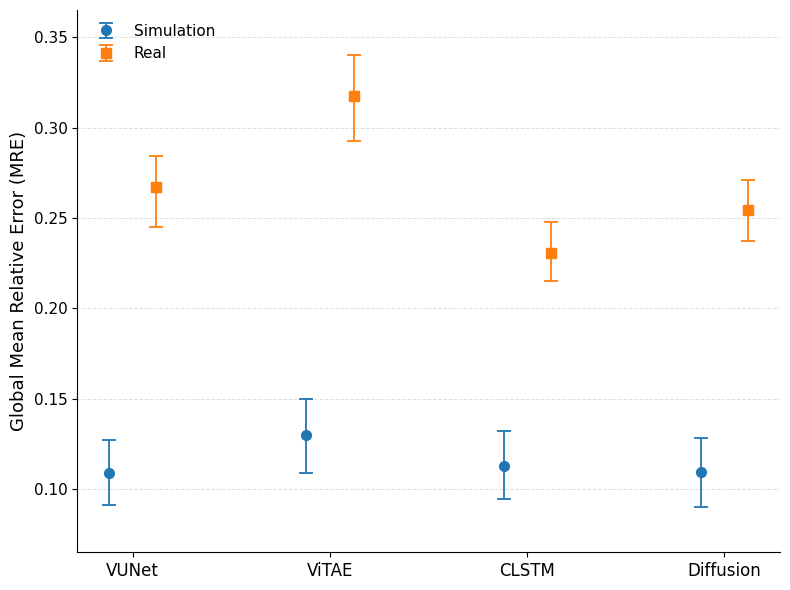

In [43]:
fig, ax = plot_global_mre_ci(
    results_global,
    save_path="paper_images/global_MRE_temporal_block_bootstrap_CI.png"
)

In [44]:
for condition in ["Simulation", "Real"]:

    print(f"\n{condition}")
    print("=" * 60)

    for model, r in results_global[condition].items():

        print(
            f"{model:12s} "
            f"MRE = {r['mean']:.4f} "
            f"95% CI = "
            f"[{r['ci_lower']:.4f}, "
            f"{r['ci_upper']:.4f}]"
        )


Simulation
VUNet        MRE = 0.1090 95% CI = [0.0911, 0.1270]
ViTAE        MRE = 0.1299 95% CI = [0.1090, 0.1497]
CLSTM        MRE = 0.1125 95% CI = [0.0946, 0.1322]
Diffusion    MRE = 0.1093 95% CI = [0.0900, 0.1281]

Real
VUNet        MRE = 0.2671 95% CI = [0.2453, 0.2844]
ViTAE        MRE = 0.3175 95% CI = [0.2924, 0.3401]
CLSTM        MRE = 0.2307 95% CI = [0.2152, 0.2480]
Diffusion    MRE = 0.2544 95% CI = [0.2370, 0.2712]
